In [4]:
import numpy as np
import seaborn as snb
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
df=pd.read_csv(r"C:\Users\HP\Downloads\your_dataset.csv")
df.head(10)

,date,product_ID,quantity_sold,sales_price,Category,customer_id,age,gender,purchase_frequency,total_purchase_amount
0,1/1/2020,22.0,112.0,44,Electronics,1,25,m,1,1132.0
1,1/2/2020,32.0,323.0,7,Clothing,2,33,m,5,2233.0
2,1/3/2020,11.0,223.0,55,Furniture,3,52,f,6,2332.0
3,1/4/2020,33.0,43.0,74,Grocery,4,29,m,8,5432.0
4,1/5/2020,26.0,643.0,39,Stationery,5,36,m,5,5544.0
5,1/6/2020,51.0,33.0,112,Stationery,6,37,m,4,5321.0
6,1/7/2020,NaN,26.0,323,Stationery,7,42,f,3,2255.0
7,1/8/2020,17.0,51.0,223,Stationery,8,23,f,3,2345.0
8,1/9/2020,22.0,22.0,43,Grocery,9,23,m,2,4325.0
9,1/10/2020,32.0,44.0,44,Clothing,10,65,f,8,NaN


In [58]:
# QUESTION 1--> How many row and columns are present?
df.shape    # ANS--> the first number represent as row.
            #        the  second number represent as columns.

(1096, 10)

In [12]:
df.size

10960

In [14]:
# QUESTION--> What is precentage of missing values exist in each column?
(df.isnull().mean()*100).round(2)

date                     0.00
 product_ID              0.18
 quantity_sold           0.18
 sales_price             0.00
Category                 0.00
customer_id              0.00
age                      0.00
gender                   0.00
purchase_frequency       0.00
total_purchase_amount    0.27
dtype: float64

In [18]:
# QUESTION---> Which colum,n have the highest  data quality issue?
(df.isnull().mean()*100).sort_values(ascending=False)

total_purchase_amount    0.273723
 product_ID              0.182482
 quantity_sold           0.182482
date                     0.000000
 sales_price             0.000000
Category                 0.000000
customer_id              0.000000
age                      0.000000
gender                   0.000000
purchase_frequency       0.000000
dtype: float64

In [28]:
df["customer_id"].duplicated().sum()

1071

In [33]:
# QUESTION---> how many records having missing
df["customer_id"].isnull().sum()

0

In [32]:
df["customer_id"].isnull().sum()

0

In [34]:
# QUESTION--> List all inconsistent category name variations.
df["Category"].value_counts()

Category
Grocery        430
Electronics    196
Clothing       196
Stationery     195
Furniture       79
Name: count, dtype: int64

In [41]:
# QUESTION--->Which rows contain extrem price outlier?
Q1=df["total_purchase_amount"].quantile(0.25)
Q3=df["total_purchase_amount"].quantile(0.75)
IQR=Q3-Q1

df[(df["total_purchase_amount"] < Q1 - 1.5 * IQR) | (df["total_purchase_amount"] > Q3 + 1.5 * IQR)]


,date,product_ID,quantity_sold,sales_price,Category,customer_id,age,gender,purchase_frequency,total_purchase_amount


In [42]:
print(Q1-1.5* IQR,Q3+1.5*IQR)

-2510.5 10197.5


In [44]:
df["total_purchase_amount"].describe()

count    1093.000000
mean     3371.989936
std      1672.811649
min      1132.000000
25%      2255.000000
50%      2356.000000
75%      5432.000000
max      5544.000000
Name: total_purchase_amount, dtype: float64

<Axes: >

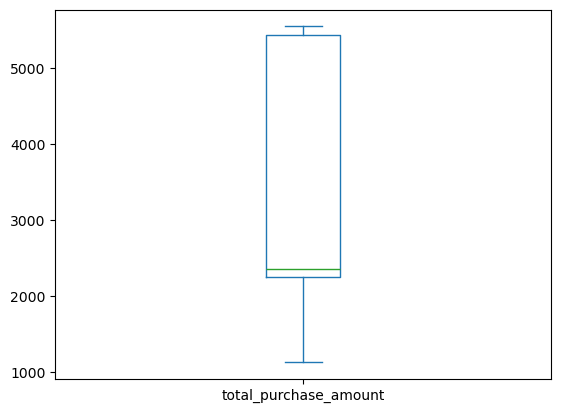

In [45]:
df["total_purchase_amount"].plot(kind="box")

In [47]:
# QUESTION---> WHICH PRODUCT CATEGORIES GENERATE THE HIGHEST TOTAL REVENUE
category_revenue = df.groupby("Category")["total_purchase_amount"].sum().sort_values(ascending=False)
print(category_revenue)

Category
Grocery        1386683.0
Clothing        730377.0
Stationery      670929.0
Electronics     627273.0
Furniture       270323.0
Name: total_purchase_amount, dtype: float64


In [48]:
# Wich sales is breakdown by customer gender?
gender=df.groupby("gender")["total_purchase_amount"].sum()
print(gender)

gender
f    1270102.0
m    2415483.0
Name: total_purchase_amount, dtype: float64


In [49]:
print(df.isnull().sum())

date                     0
 product_ID              2
 quantity_sold           2
 sales_price             0
Category                 0
customer_id              0
age                      0
gender                   0
purchase_frequency       0
total_purchase_amount    3
dtype: int64


In [55]:
# what is total purchase amount?
df['total_purchase_amount'].sum()

3685585.0

In [60]:
# what is average customer id  values?
df.groupby('customer_id')['total_purchase_amount'].sum().mean()

147423.4

In [61]:
# which is heighest Category purchase?
df.groupby("Category")['total_purchase_amount'].sum().sort_values(ascending=False).head(1)

Category
Grocery    1386683.0
Name: total_purchase_amount, dtype: float64

In [63]:
# which gender perfrom best overall?
df.groupby ("gender")['total_purchase_amount'].sum().sort_values(ascending=False)


gender
m    2415483.0
f    1270102.0
Name: total_purchase_amount, dtype: float64

In [66]:
# top 10 date by total purchase amount?
df.groupby("date")['total_purchase_amount'].sum().sort_values(ascending=False).head(10)

date
11/14/2020    5544.0
8/1/2021      5544.0
9/10/2021     5544.0
10/21/2022    5544.0
9/1/2022      5544.0
3/15/2020     5544.0
5/8/2022      5544.0
9/1/2020      5544.0
4/19/2021     5544.0
6/28/2021     5544.0
Name: total_purchase_amount, dtype: float64

In [68]:
# which category contributes most amount?
df.groupby("Category")['total_purchase_amount'].sum().sort_values(ascending=False)

Category
Grocery        1386683.0
Clothing        730377.0
Stationery      670929.0
Electronics     627273.0
Furniture       270323.0
Name: total_purchase_amount, dtype: float64

In [69]:
# least perfroming category?
df.groupby("Category")['total_purchase_amount'].sum().sort_values().head(1)

Category
Furniture    270323.0
Name: total_purchase_amount, dtype: float64

In [72]:
# median total_purchase_amount per order?
df['total_purchase_amount'].mean()

3371.989935956084

In [74]:
# which gender order most?
df["gender"].value_counts().idxmax()

'm'

section 3 ---> time based Analysis

In [75]:
# date total amount purchase amount trend?
df.groupby(['date'])['total_purchase_amount'].sum()

date
1/1/2020     1132.0
1/1/2021     2255.0
1/1/2022     2233.0
1/10/2020       0.0
1/10/2021    1132.0
              ...  
9/8/2021     2332.0
9/8/2022     2233.0
9/9/2020     2332.0
9/9/2021     5432.0
9/9/2022     2332.0
Name: total_purchase_amount, Length: 1096, dtype: float64

In [77]:
# heighest date sales ?
df.groupby('date')['total_purchase_amount'].sum().idxmax()

'1/13/2021'

In [78]:
# lowest date sales?
df.groupby('date')['total_purchase_amount'].sum().idxmin()

'1/10/2020'

In [79]:
# date wise average?
df.groupby('date')['total_purchase_amount'].mean()

date
1/1/2020     1132.0
1/1/2021     2255.0
1/1/2022     2233.0
1/10/2020       NaN
1/10/2021    1132.0
              ...  
9/8/2021     2332.0
9/8/2022     2233.0
9/9/2020     2332.0
9/9/2021     5432.0
9/9/2022     2332.0
Name: total_purchase_amount, Length: 1096, dtype: float64

In [82]:
# Calculate the average age of buyers for each category
avg_age_per_category = df.groupby('Category')['age'].mean().reset_index()

# Sort from youngest to oldest average buyer
avg_age_per_category = avg_age_per_category.sort_values(by='age')

print(avg_age_per_category)

      Category        age
1  Electronics  39.969388
2    Furniture  40.050633
3      Grocery  40.309302
4   Stationery  40.425641
0     Clothing  40.826531


Visualization tests

AttributeError: module 'matplotlib.pyplot' has no attribute 'ylable'

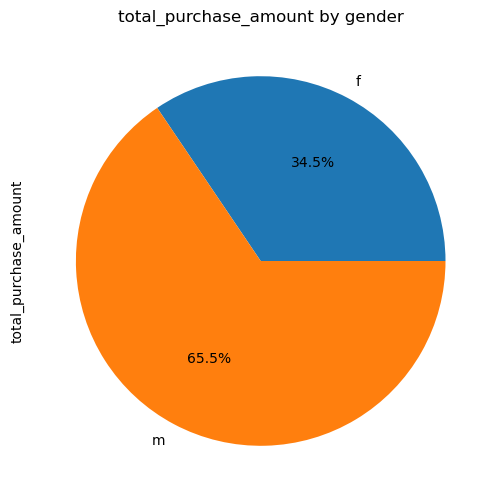

In [96]:
# gender revenue pie chart?
total_purchase_amount=df.groupby("gender")["total_purchase_amount"].sum()

total_purchase_amount.plot(kind="pie",autopct='%1.1f%%',figsize=(6,6))
plt.title("total_purchase_amount by gender") 
plt.ylable('')
plt.show()                           



<function matplotlib.pyplot.show(close=None, block=None)>

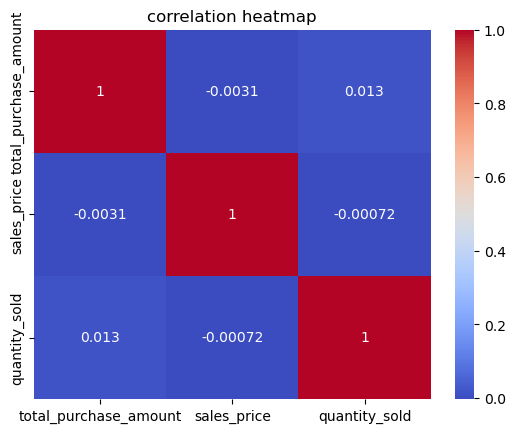

In [98]:
# correlation heatmap?
import seaborn as sns
corr=df[['total_purchase_amount','sales_price','quantity_sold']].corr()
sns.heatmap(corr,annot=True, cmap='coolwarm')
plt.title("correlation heatmap")
plt.show

 CONCLUSIONS

Missing Data: the dateset contain missing values (nan) in critical columns like product_id (index 6) and total amount (index 9).these requires data 
cleaning before analysis.

TOP Performing category : Grocery is the highest individual transcation values ,highlighted by a single 1386683.0

Purchase Frequency : customer purchase frequencies very widely ,ranging from at one time buyers (  frequency of 1) to highly frequent shopper(frequency 
                     of 9)   
DEMOGRAPHICS TRENDS : Its Show (MALE) Customer base buying across variour categories like electron,clothing,stationery etc
                     